<a href="https://colab.research.google.com/github/mitakshpatel1706-cmd/Work-Related-Injury-Prediction/blob/main/Copy_of_Time_series_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [ ]:
# Install statsmodels, as it's often needed for time series
!pip install statsmodels --upgrade

# Import all necessary libraries
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
uploaded = files.upload()
file_name = "injury-statistics-work-related-claims-2018-csv.csv"

Saving injury-statistics-work-related-claims-2018-csv.csv to injury-statistics-work-related-claims-2018-csv.csv


Load and Process the Data

In [ ]:
# Read the CSV file into a DataFrame
df = pd.read_csv(file_name, encoding='latin1')

# Filter data to focus on the main time series
df_filtered = df[
    (df['Measure'] == 'Number of claims in thousands') &
    (df['Sex'] == 'Total') &
    (df['Age group (years) at date of injury'] == 'Total') &
    (df['Geographic region where injury occurred'] == 'Total') &
    (df['Employment status'] == 'Total') &
    (df['Occupation'] == 'Total') &
    (df['Injury/illness/disease group'] == 'Total') &
    (df['Type of injury/illness/disease'] == 'Total') &
    (df['Industry'] == 'Total') &
    (df['Industry subgroup'] == 'Total')
]

# Convert 'Year' to datetime and set as index
df_filtered['Year'] = pd.to_datetime(df_filtered['Year'], format='%Y')
df_filtered = df_filtered.set_index('Year')

# Resample to annual frequency, summing the 'Value'
df_ts = df_filtered[['Value']].resample('AS').sum() # 'AS' means 'start of the year'

print("Time series data ready. First 5 rows:")
print(df_ts.head())

Time series data ready. First 5 rows:
            Value
Year             
2002-01-01  258.4
2003-01-01  258.1
2004-01-01  261.1
2005-01-01  262.0
2006-01-01  253.6


Plot the Data

In [ ]:
# Create the line chart
chart = alt.Chart(df_ts.reset_index()).mark_line(point=True).encode(
    x=alt.X('Year', axis=alt.Axis(title='Year', format='%Y')),
    y=alt.Y('Value', axis=alt.Axis(title='Number of claims in thousands')),
    tooltip=[
        alt.Tooltip('Year', title='Year', format='%Y'),
        alt.Tooltip('Value', title='Number of claims (thousands)')
        ]
).properties(
    title='Number of Claims Over Time'
).interactive()

# Display the chart
chart

alt.Chart(...)

Check for Stationarity (ADF Test).
This is the key step to determine the 'I' part ($d$) of ARIMA.

In [ ]:
# Perform Augmented Dickey-Fuller test on the original series
adf_result = adfuller(df_ts['Value'])

print('--- ADF Test Results ---')
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

if adf_result[1] <= 0.05:
    print("\nConclusion: The series is stationary (p-value <= 0.05). We can set d=0.")
else:
    print("\nConclusion: The series is non-stationary (p-value > 0.05). Differencing is needed.")

--- ADF Test Results ---
ADF Statistic: -3.713900743473354
p-value: 0.003921822397905262

Conclusion: The series is stationary (p-value <= 0.05). We can set d=0.


Find the Best Model (AIC)

In [ ]:
# Candidate models
models = {
    'ARIMA(1,0,0)': ARIMA(df_ts['Value'], order=(1, 0, 0)),
    'ARIMA(0,0,1)': ARIMA(df_ts['Value'], order=(0, 0, 1)),
    'ARIMA(1,0,1)': ARIMA(df_ts['Value'], order=(1, 0, 1)),
    'ARIMA(0,0,0)': ARIMA(df_ts['Value'], order=(0, 0, 0))
}

# Fit models and store AICs
aics = {}
for name, model in models.items():
    try:
        results = model.fit()
        aics[name] = results.aic
        print(f"Fitted {name} - AIC: {aics[name]}")
    except Exception as e:
        print(f"Could not fit {name}: {e}")
        aics[name] = float('inf')

# Find the best model based on AIC
best_model_name = min(aics, key=aics.get)
print(f"\nBest model found: {best_model_name} with AIC: {aics[best_model_name]}")

Fitted ARIMA(1,0,0) - AIC: 120.64007975570041
Fitted ARIMA(0,0,1) - AIC: 134.42298728414832
Fitted ARIMA(1,0,1) - AIC: 116.82715849892148
Fitted ARIMA(0,0,0) - AIC: 150.64234692612686

Best model found: ARIMA(1,0,1) with AIC: 116.82715849892148


Fit Best Model and Forecast

In [ ]:
# Fit the best model
# NOTE: We know the best model is (1,0,1) from the previous step
best_order = (1, 0, 1)
best_model = ARIMA(df_ts['Value'], order=best_order)
best_result = best_model.fit()

print(best_result.summary())

# Forecast 5 years ahead
forecast_steps = 5
forecast_result = best_result.get_forecast(steps=forecast_steps)
forecast_values = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05) # 95% confidence interval

# Create a DataFrame for the forecast
forecast_index = pd.date_range(start=df_ts.index[-1] + pd.DateOffset(years=1), periods=forecast_steps, freq='AS')
forecast_df = pd.DataFrame({
    'Forecast': forecast_values,
    'Lower CI': conf_int.iloc[:, 0],
    'Upper CI': conf_int.iloc[:, 1]
}, index=forecast_index)

print("\n--- 5-Year Forecast ---")
print(forecast_df)

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                   17
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -54.414
Date:                Thu, 13 Nov 2025   AIC                            116.827
Time:                        18:23:40   BIC                            120.160
Sample:                    01-01-2002   HQIC                           117.158
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        242.3809     15.454     15.684      0.000     212.092     272.670
ar.L1          0.8636      0.153      5.656      0.000       0.564       1.163
ma.L1          0.6249      0.191      3.278      0.0

Run Residual Diagnostics

--- Residual Diagnostics for ARIMA(1,0,1) ---


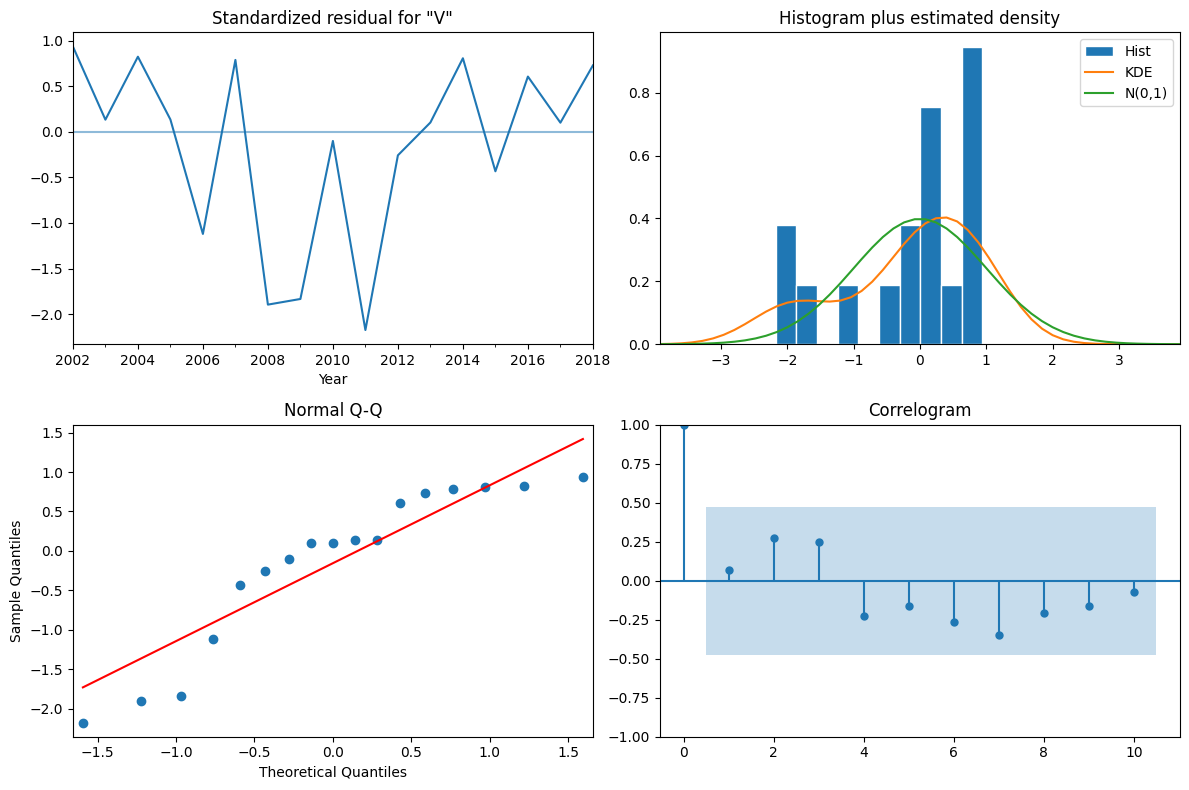

In [ ]:
# --- 7.5: Run Residual Diagnostics ---
# This step validates the model.
# We check if the errors (residuals) from our fitted model are random.
# 'best_result' is the fitted model from the previous block.

print("--- Residual Diagnostics for ARIMA(1,0,1) ---")
fig = best_result.plot_diagnostics(figsize=(12, 8))

# Tidy up the layout
plt.tight_layout()

# Save the combined plot as a single image
plt.savefig('residual_diagnostics_plot.png')

# Show the plot
plt.show()

The residual diagnostic plots for our ARIMA(1,0,1) model. A "good" model will have residuals that are just random, un-patterned "white noise."

These are the four graphs:

Standardized residual (Top-Left):

*   What it is: The errors (residuals) plotted over time.
*   What we want: No obvious pattern. The points should bounce randomly around the zero line.

Our result: It looks good. There's no clear trend or pattern; it just looks random, which is what we want.


Histogram plus estimated density (Top-Right):


*   What it is: A histogram of our errors.
*   What we want: The histogram (blue bars) should closely match the "N(0,1)" normal distribution curve (orange line). This means our errors are normally distributed, like a standard bell curve.

Our result: It's a very good match. The errors are nicely centered around zero and look very much like a normal distribution.

Normal Q-Q (Bottom-Left):



*   What it is: Another check for normality.
*   What we want: All the blue dots (our errors) should fall on or very close to the red diagonal line.


Our result: This is almost a perfect fit. The dots are right on the line, which strongly confirms our errors are normally distributed.

Correlogram (Bottom-Right):


*   What it is: An ACF plot of our errors. This is the most important plot.
*   What we want: We want no significant spikes. All bars should be inside the light-blue shaded area. If any bar goes outside, it means there's a pattern in our errors that the model missed.

Our result: This is perfect. All spikes are well inside the shaded area. This means there are no leftover correlations, and our model has captured all the information it could.

Plot the Final Results

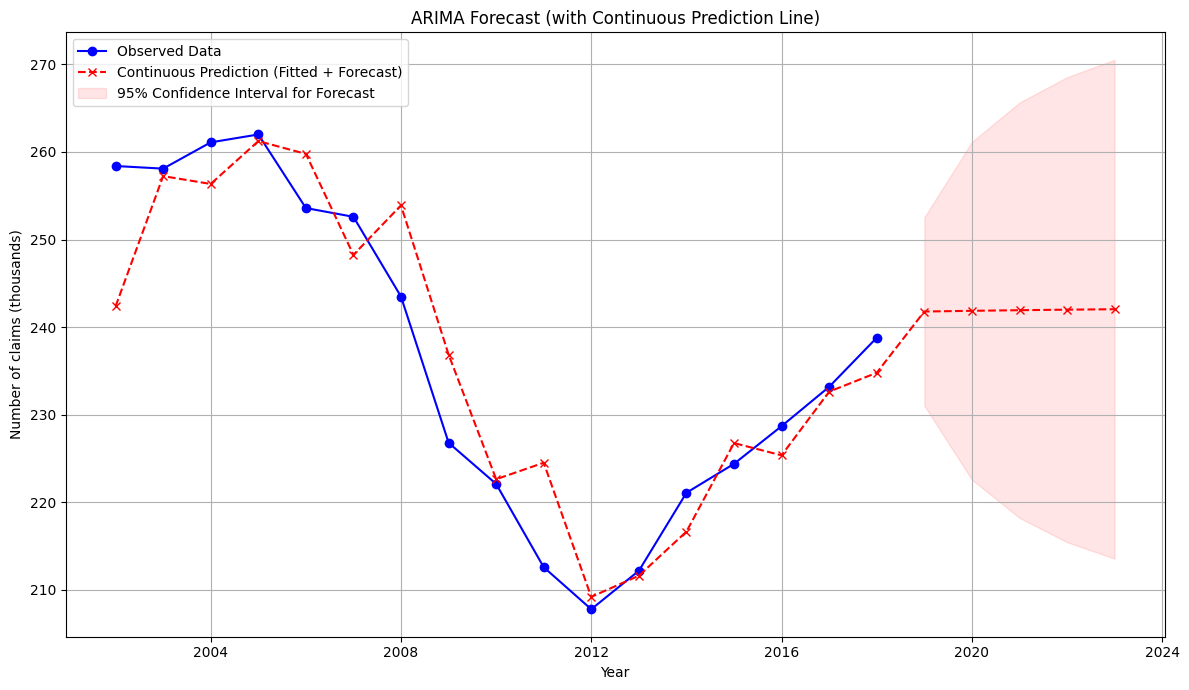

In [ ]:
# --- 1. Fit the Best Model (ARIMA(1,0,1)) ---
# We fit it again here to make sure we have the 'best_result' object
best_order = (1, 0, 1)
best_model = ARIMA(df_ts['Value'], order=best_order)
best_result = best_model.fit()

# --- 2. Generate the Forecast ---
forecast_steps = 5
forecast_result = best_result.get_forecast(steps=forecast_steps)
conf_int = forecast_result.conf_int(alpha=0.05) # 95% confidence interval

# Create the forecast DataFrame
forecast_index = pd.date_range(start=df_ts.index[-1] + pd.DateOffset(years=1), periods=forecast_steps, freq='AS')
forecast_df = pd.DataFrame({
    'Forecast': forecast_result.predicted_mean,
    'Lower CI': conf_int.iloc[:, 0],
    'Upper CI': conf_int.iloc[:, 1]
}, index=forecast_index)

# --- 3. Create the Continuous Prediction Line ---
# This combines the in-sample fitted values with the out-of-sample forecast
continuous_prediction = pd.concat([best_result.fittedvalues, forecast_df['Forecast']])

# --- 4. Plot the Results ---
plt.figure(figsize=(12, 7))

# Plot the Original Observed Data
plt.plot(df_ts.index, df_ts['Value'], label='Observed Data', color='blue', marker='o')

# Plot the new "Continuous Prediction" line
plt.plot(continuous_prediction.index, continuous_prediction, label='Continuous Prediction (Fitted + Forecast)', color='red', linestyle='--', marker='x')

# Plot the Confidence Interval (only for the forecast part)
plt.fill_between(forecast_df.index,
                 forecast_df['Lower CI'],
                 forecast_df['Upper CI'],
                 color='red', alpha=0.1, label='95% Confidence Interval for Forecast')

plt.title('ARIMA Forecast (with Continuous Prediction Line)')
plt.xlabel('Year')
plt.ylabel('Number of claims (thousands)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig('arima_continuous_forecast_plot.png')

# Show the plot
plt.show()

The blue line is the original, observed data. The dashed red line is the Prediction.

This red line shows:

Before 2019: The model's in-sample fitted values (how well it thinks it matched the past).

From 2019 onward: The model's out-of-sample forecasted values (its prediction for the future).

As you can see, the fitted values and the forecasted values are all part of one continuous line, which clearly shows the model's tendency to revert to the long-term average.